# Project Option 1: Enforcing Agentic Reasoning (formatting)

### **Objective**: Teach a small language model to strictly adhere to a complex, multi-step XML reasoning format using rule-based RL, effectively creating a miniature "DeepSeek-R1" style reasoner.

**What we will do**
- Fine-tune `Llama-3.2-1B-Instruct` on GSM8K math problems using **RLOO with PPO-style clipping** — the leave-one-out baseline of REINFORCE/RLOO combined with a clipped importance-sampling ratio and multiple gradient steps per rollout (the same recipe used by GRPO and modern LLM-RL stacks).
- Use a **rule-based reward**: format compliance (`<think>...</think>`) + answer correctness — no learned reward model.
- Apply **KL regularization** against a frozen reference policy as a *separate loss term* (not folded into the reward) so the model picks up the new format without drifting away from its pretrained distribution.

**Why RLOO + clipping?** Plain RLOO is sample-inefficient — every rollout is used for a single gradient step. PPO clipping lets us safely take *several* gradient steps on the same rollout: as the new policy drifts from the sampling policy, the clipped surrogate caps each token's contribution, preventing the kind of off-policy blow-ups that pure REINFORCE suffers from. We keep RLOO's leave-one-out baseline (cheap, no critic) and gain PPO's update efficiency.

In [1]:
# Run on login node to download model and tokenizer if needed
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from huggingface_hub import login

login()  

model_name = "meta-llama/Llama-3.2-1B-Instruct"

# Download and cache model + tokenizer
AutoTokenizer.from_pretrained(model_name)
AutoModelForCausalLM.from_pretrained(model_name)

# Download and cache dataset
load_dataset("openai/gsm8k", "main")

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['question', 'answer'],
        num_rows: 7473
    })
    test: Dataset({
        features: ['question', 'answer'],
        num_rows: 1319
    })
})

In [1]:
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)

print(f"torch:  {torch.__version__}")
print(f"device: {device}")
if torch.cuda.is_available():
    print(f"GPU:    {torch.cuda.get_device_name(0)}")

torch:  2.5.1+cu121
device: cuda
GPU:    NVIDIA A100-SXM-64GB


In [2]:
# Tell hf to use cached files and not try to connect to the internet

import os
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_DATASETS_OFFLINE"] = "1"

## RLOO from scratch on a tiny Llama-3.2 model

We'll teach `Llama-3.2-1B-Instruct` to produce well-formatted XML reasoning steps. The reward is rule-based (XML structure + answer correctness) and we use KL-regularization against a frozen reference policy.

**Two policies are needed:**
- `policy` — trainable; this is the one whose log-probs we differentiate.
- `ref_policy` — a frozen copy used only to evaluate $\mathrm{KL}(\pi_\theta \;\|\; \pi_\text{ref})$. We put it in `eval()` mode and freeze its parameters: no optimizer state is allocated, no activations are stored for backward, and it cannot drift.

In [3]:
model_name = "meta-llama/Llama-3.2-1B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# Trainable policy + frozen reference (see explanation above).
policy = AutoModelForCausalLM.from_pretrained(model_name).to(device)
ref_policy = AutoModelForCausalLM.from_pretrained(model_name).to(device)
ref_policy.eval()
for p in ref_policy.parameters():
    p.requires_grad_(False)

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Import the dataset and extract the ground truth answers for reward computation. 

In [4]:
import re
from datasets import load_dataset

dataset = load_dataset("openai/gsm8k", "main")
train_data = dataset["train"]
test_data = dataset["test"]

THINK_TAG = "think"


def has_valid_format(text: str) -> bool:
    """True iff the completion has <think>...</think> exactly once, followed by a final answer."""
    opening = text.count(f"<{THINK_TAG}>")
    closing = text.count(f"</{THINK_TAG}>")
    if opening != 1 or closing != 1: # Both of them should appear exactly once
        return False
    pattern = rf"^\s*<{THINK_TAG}>.+?</{THINK_TAG}>\s*\S+" #  Valid format: <think>...</think> followed by some non-whitespace characters (the answer)
    return bool(re.search(pattern, text, re.DOTALL))


def extract_answer(text: str) -> str:
    """Return the text after the *last* </think>, with Llama special tokens (<|eot_id|>, ...) stripped.
    Using parts[-1] handles malformed completions with multiple </think> tags — the final answer is
    whatever follows the last closing tag, not the text between intermediate tags.
    """
    parts = text.split(f"</{THINK_TAG}>")
    if len(parts) <= 1:
        return ""
    answer = re.sub(r"<\|[^|]+\|>", "", parts[-1])
    return answer.strip()


def is_answer_correct(predicted: str, ground_truth: str) -> bool:
    """
    Robust numeric match: the GT must appear as a stand-alone token in the prediction.
    Using regex word-boundaries on digits prevents spurious matches like '42' in '420'.
    """
    if not ground_truth:
        return False
    return re.search(rf"(?<!\d){re.escape(ground_truth)}(?!\d)", predicted) is not None


def reward_fn(completions: list[str], ground_truths: list[str]) -> list[float]:
    """
    Rule-based reward.
      +0.1  well-formed <think>...</think> followed by an answer
      -0.2  malformed structure
      +1.0  predicted answer matches the ground-truth number
      -0.5  predicted answer does not match the ground-truth number

    The format component is intentionally small relative to the correctness component:
    the model is steered toward "be correct AND clean", not toward gaming the format.
    """
    assert len(completions) == len(ground_truths), "completions / ground_truths length mismatch"
    rewards = []
    for completion, gt in zip(completions, ground_truths):
        r = 0.1 if has_valid_format(completion) else -0.2
        if is_answer_correct(extract_answer(completion), gt):
            r += 1.0
        else:
            r -= 0.5
        rewards.append(r)
    return rewards


def extract_ground_truth(answer_str: str) -> str:
    """GSM8K stores the gold answer after a `####` marker."""
    match = re.search(r"####\s*(-?\d+)", answer_str)
    return match.group(1).strip() if match else ""


# Quick sanity checks
print("Extracted GT from '#### 42':           ", extract_ground_truth("The answer is 42. #### 42"))
print("is_answer_correct('the answer is 42'): ", is_answer_correct("the answer is 42", "42"))
print("is_answer_correct('the answer is 420'):", is_answer_correct("the answer is 420", "42"))

Using the latest cached version of the dataset since openai/gsm8k couldn't be found on the Hugging Face Hub (offline mode is enabled).
Found the latest cached dataset configuration 'main' at $HOME/.cache/huggingface/datasets/openai___gsm8k/main/0.0.0/740312add88f781978c0658806c59bc2815b9866 (last modified on Thu May  7 15:11:24 2026).


Extracted GT from '#### 42':            42
is_answer_correct('the answer is 42'):  True
is_answer_correct('the answer is 420'): False


### One RLOO+clipping step

We split each step into two phases — **rollout** (collect data, no gradients) and **update** (multiple gradient steps on the cached rollout).

**Rollout phase** (`rollout`):
1. Repeat the prompt **K** times and sample K completions in one batched `generate` call.
2. Score each completion with `reward_fn`.
3. Cache per-token log-probs under (a) the *sampling* policy — these become $\log\pi_{\text{old}}$ for the importance ratio — and (b) the frozen reference $\log\pi_{\text{ref}}$.
4. Build the leave-one-out advantage: $A^{(i)} = r^{(i)} - \tfrac{1}{K-1}\sum_{j\ne i}r^{(j)} = \tfrac{K}{K-1}(r^{(i)}-\bar r)$. Note: KL is *not* folded into the reward here — it appears as a separate loss term during the update phase.

**Update phase** (`ppo_update`, run `PPO_EPOCHS` times per rollout):
1. Recompute per-token log-probs $\log\pi_\theta$ under the *current* policy (with grad).
2. Form the per-token importance ratio $\rho_t = \exp(\log\pi_\theta(a_t) - \log\pi_{\text{old}}(a_t))$.
3. Apply the **clipped surrogate** with the per-sequence advantage broadcast over tokens:
   $$\mathcal{L}_{\text{PG}} = -\mathbb{E}_t\Big[\min\big(\rho_t A,\; \mathrm{clip}(\rho_t, 1-\epsilon, 1+\epsilon)\, A\big)\Big]$$
4. Add a separate K3 KL penalty against the frozen reference (computed on the *current* policy, so it tightens as $\pi_\theta$ drifts):
   $$\mathcal{L} = \mathcal{L}_{\text{PG}} + \beta\,\widehat{\mathrm{KL}}_{\text{k3}}(\pi_\theta\,\|\,\pi_{\text{ref}})$$

The *first* inner epoch has $\rho_t \equiv 1$ and is identical to plain RLOO. Subsequent epochs reuse the same K samples but with the new policy — clipping is what makes that off-policy reuse safe. We also log the **clip fraction** (share of tokens where $\rho_t$ left $[1-\epsilon, 1+\epsilon]$) as a diagnostic: too high (≫ 0.3) means the inner loop is too aggressive (lower lr or fewer epochs).

In [5]:
SYSTEM_PROMPT = (
    "You are a helpful and concise assistant for solving grade-school math problems. "
    "Solve the following math problem. You must think step-by-step and place all your "
    "reasoning strictly inside <think> and </think> tags. "
    "After closing the tags, provide your final answer."
)


def format_prompt(question: str) -> str:
    """Build a chat-formatted prompt with one in-context demo of the desired format."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": "What is 2+3?"},
        {"role": "assistant", "content": "<think>I need to add 2 and 3. 2 + 3 = 5. </think> 5"},
        {"role": "user", "content": question},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


def _token_logp(model, full_ids, completions, prompt_len):
    """Per-token log-prob of `completions` under `model`, on the slice that aligns
    causal-LM logits with the generated tokens (logits[t] predicts token t+1)."""
    logits = model(full_ids).logits[:, prompt_len - 1:-1, :]
    return F.log_softmax(logits, dim=-1).gather(2, completions.unsqueeze(-1)).squeeze(-1)


def rollout(prompt, ground_truth, K=4, max_new_tokens=1000):
    """Sample K completions and cache everything the inner update loop will need.

    No gradients here — this is data collection. `logp_old` is the log-prob under the
    policy *at sampling time*; it becomes the denominator of the importance ratio
    during the update phase.
    """
    formatted_prompt = format_prompt(prompt)
    enc = tokenizer(formatted_prompt, return_tensors="pt").to(device)
    prompt_ids = enc.input_ids.repeat(K, 1)
    prompt_len = prompt_ids.shape[1]

    with torch.no_grad():
        full_ids = policy.generate(
            prompt_ids,
            max_new_tokens=max_new_tokens,
            do_sample=True, top_k=50, top_p=0.95,
            pad_token_id=tokenizer.eos_token_id,
        )
    completions = full_ids[:, prompt_len:]
    texts = tokenizer.batch_decode(completions, skip_special_tokens=True)

    # Mask is 1 up to (and including) the first EOS, 0 afterwards.
    is_eos = (completions == tokenizer.eos_token_id)
    gen_mask = (is_eos.cumsum(dim=1) <= 1).float()

    rewards = torch.tensor(
        reward_fn(texts, ground_truths=[ground_truth] * K),
        dtype=torch.float32, device=device,
    )

    with torch.no_grad():
        logp_old = _token_logp(policy,     full_ids, completions, prompt_len)
        logp_ref = _token_logp(ref_policy, full_ids, completions, prompt_len)

    # Leave-one-out advantage on raw reward (KL is now a separate loss term, not in the reward).
    baseline = (rewards.sum() - rewards) / (K - 1)
    advantage = (rewards - baseline).detach()  # shape [K]

    return {
        "full_ids": full_ids,
        "completions": completions,
        "prompt_len": prompt_len,
        "gen_mask": gen_mask,
        "rewards": rewards,
        "advantage": advantage,
        "logp_old": logp_old.detach(),
        "logp_ref": logp_ref.detach(),
        "texts": texts,
    }


def ppo_update(batch, kl_coef=0.2, clip_eps=0.2):
    """One gradient step: clipped surrogate + KL-to-reference penalty.

    Per-sequence advantages are broadcast over tokens; clipping is applied per-token.
    KL is computed on the *current* policy each call, so it tightens as π_θ drifts.
    """
    full_ids    = batch["full_ids"]
    completions = batch["completions"]
    prompt_len  = batch["prompt_len"]
    gen_mask    = batch["gen_mask"]
    advantage   = batch["advantage"]    # [K]
    logp_old    = batch["logp_old"]     # [K, T]
    logp_ref    = batch["logp_ref"]     # [K, T]

    n_gen = gen_mask.sum().clamp(min=1.0)
    seq_lengths = gen_mask.sum(dim=1).clamp(min=1.0)

    logp_p = _token_logp(policy, full_ids, completions, prompt_len)  # with grad

    # Clipped surrogate (per-token ratio, per-sequence advantage broadcast).
    ratio = torch.exp(logp_p - logp_old)                # [K, T]
    adv_t = advantage.unsqueeze(1)                       # [K, 1] -> broadcasts to [K, T]
    surr1 = ratio * adv_t
    surr2 = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * adv_t
    pg_loss = -(torch.min(surr1, surr2) * gen_mask).sum() / n_gen

    # K3 KL estimator: k3 = exp(-Δ) + Δ - 1, with Δ = log π_θ - log π_ref. Always ≥ 0.
    log_ratio_ref = logp_p - logp_ref
    k3_kl = torch.exp(-log_ratio_ref) + log_ratio_ref - 1.0
    kl_per_seq = (k3_kl * gen_mask).sum(dim=1) / seq_lengths
    kl_loss = kl_per_seq.mean()

    loss = pg_loss + kl_coef * kl_loss

    # Diagnostic: fraction of generated tokens whose ratio left [1-eps, 1+eps].
    with torch.no_grad():
        clipped = ((ratio < 1.0 - clip_eps) | (ratio > 1.0 + clip_eps)).float()
        clip_frac = (clipped * gen_mask).sum() / n_gen

    return loss, pg_loss.detach(), kl_per_seq.detach(), clip_frac.detach()

In [6]:
# Quick sanity check: does the base model already follow the format on a trivial prompt?

prompt = "If you have 3 apples and you buy 2 more, how many apples do you have in total?"
formatted_prompt = format_prompt(prompt)
enc = tokenizer(formatted_prompt, return_tensors="pt").to(device)
prompt_len = enc.input_ids.shape[1]

with torch.no_grad():
    full_ids = policy.generate(
        enc.input_ids,
        attention_mask=enc.attention_mask,
        max_new_tokens=500,
        do_sample=True, top_k=50, top_p=0.95,   # match the sampling settings used in training
        pad_token_id=tokenizer.eos_token_id,
    )

# Keep special tokens here so we can see <|eot_id|> etc. in the raw output.
text = tokenizer.batch_decode(full_ids[:, prompt_len:], skip_special_tokens=False)[0]
answer = extract_answer(text)

print("Completion:", text)
print("\nFormat OK?  ", has_valid_format(text))
print("Answer OK?  ", is_answer_correct(answer, "5"))
print("Answer:     ", answer if answer else "(none extracted)")

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Completion: <think>I start with 3 apples. I buy 2 more. To find the total, I need to add 3 + 2. 3 + 2 = 5. I have 5 apples now. </think> 5<|eot_id|>

Format OK?   True
Answer OK?   True
Answer:      5


Check accuracy of the base model before training to establish a baseline.

In [7]:
def check_accuracy(completions: list[str], ground_truths: list[str]) -> tuple[float, float, float]:
    """Return (format_accuracy, answer_accuracy, both_accuracy):
      - format_accuracy: fraction of completions with a well-formed <think>...</think> block.
      - answer_accuracy: fraction of completions whose extracted answer contains the ground-truth integer,
        regardless of whether the format was valid.
      - both_accuracy:   fraction where both conditions hold.
    """
    if not ground_truths:
        return 0.0, 0.0, 0.0
    n = len(ground_truths)
    format_correct = sum(has_valid_format(c) for c in completions)
    answer_correct = sum(
        is_answer_correct(extract_answer(c), gt)
        for c, gt in zip(completions, ground_truths)
    )
    both_correct = sum(
        has_valid_format(c) and is_answer_correct(extract_answer(c), gt)
        for c, gt in zip(completions, ground_truths)
    )
    return format_correct / n, answer_correct / n, both_correct / n


def evaluate_policy(
    num_questions: int, max_new_tokens: int = 1000
) -> tuple[float, float, float, float, list[str], list[str]]:
    """Greedy-decode the policy on the first N test questions and measure drift from the reference.

    Returns
    -------
    format_acc, answer_acc, both_acc : float
        See `check_accuracy`.
    mean_kl : float
        Mean K3 KL(π_θ ‖ π_ref) per token, averaged across completions. Same estimator as the
        training loss, so the eval number is directly comparable to `log_kls` from the loop.
    completions, ground_truths : list[str]
    """
    questions = [item["question"] for item in test_data][:num_questions]
    gts = [extract_ground_truth(item["answer"]) for item in test_data][:num_questions]

    policy.eval()  # disable dropout etc. during evaluation
    completions, kls = [], []
    for step, q in enumerate(questions, start=1):
        formatted_prompt = format_prompt(q)
        enc = tokenizer(formatted_prompt, return_tensors="pt").to(device)
        prompt_len = enc.input_ids.shape[1]
        with torch.no_grad():
            full_ids = policy.generate(
                enc.input_ids,
                attention_mask=enc.attention_mask,
                max_new_tokens=max_new_tokens,
                do_sample=False,                      # greedy → deterministic, fair comparison
                pad_token_id=tokenizer.eos_token_id,
            )
        comp_ids = full_ids[:, prompt_len:]
        text = tokenizer.batch_decode(comp_ids, skip_special_tokens=True)[0]
        completions.append(text)

        # Mask is 1 up to (and including) the first EOS, 0 afterwards — same convention as `rollout`.
        is_eos = (comp_ids == tokenizer.eos_token_id)
        gen_mask = (is_eos.cumsum(dim=1) <= 1).float()
        seq_len = gen_mask.sum(dim=1).clamp(min=1.0)

        # K3 estimator: matches the one used in `ppo_update`, so values are directly comparable.
        with torch.no_grad():
            logp_p   = _token_logp(policy,     full_ids, comp_ids, prompt_len)
            logp_ref = _token_logp(ref_policy, full_ids, comp_ids, prompt_len)
            log_ratio = logp_p - logp_ref
            k3 = torch.exp(-log_ratio) + log_ratio - 1.0
            kl_per_seq = (k3 * gen_mask).sum(dim=1) / seq_len
        kls.append(kl_per_seq.item())

        if step % 10 == 0:
            print(f"[eval] {step:3d}/{len(questions)}  kl={kl_per_seq.item():.4f}  sample: {text!r}")

    format_acc, answer_acc, both_acc = check_accuracy(completions, gts)
    mean_kl = sum(kls) / len(kls) if kls else 0.0
    return format_acc, answer_acc, both_acc, mean_kl, completions, gts

Presentation of the scores

In [8]:
from dataclasses import dataclass
from typing import Optional

@dataclass
class EvaluationSummary:
    format_acc: float
    answer_acc: float
    both_acc: float
    num_questions: int
    kl_div: Optional[float] = None  # mean K3 KL(π_θ ‖ π_ref) per token; None if not measured

    def report(self, title: str = "Baseline Policy Evaluation"):
        """Renders a professional, aligned table output."""

        metrics = {
            "Format Accuracy": self.format_acc,
            "Answer Accuracy": self.answer_acc,
            "Combined (Format + Answer)": self.both_acc,
        }

        border = "═" * 60
        print(f"\n{border}")
        print(f"{title:^60}")
        print(f"{border}")
        print(f"{'Metric':<35} | {'Percentage':<12} | {'Raw Score'}")
        print("-" * 60)

        for label, value in metrics.items():
            pct = f"{value * 100:>6.2f}%"
            count = f"{int(value * self.num_questions)}/{self.num_questions}"
            print(f"{label:<35} | {pct:<12} | {count}")

        if self.kl_div is not None:
            print("-" * 60)
            kl_str = f"{self.kl_div:.4f}"
            print(f"{'KL(π_θ ‖ π_ref) / token (K3)':<35} | {kl_str:<12} | mean over completions")

        print(f"{border}\n")

# Usage
NUM_QUESTIONS = 100
(
    f_acc, a_acc, b_acc, mean_kl,
    completions, ground_truths
) = evaluate_policy(NUM_QUESTIONS)

results = EvaluationSummary(f_acc, a_acc, b_acc, NUM_QUESTIONS, kl_div=mean_kl)
results.report()


[eval]  10/100  kl=0.0000  sample: "<think>First, let's calculate Eliza's regular pay for 40 hours. 40 hours * $10/hour = $400. Then, let's calculate her overtime pay. 45 hours * 1.2 * $10/hour = $360. Now, let's add her regular pay and overtime pay. $400 + $360 = $760. </think> 760"
[eval]  20/100  kl=0.0000  sample: '<think>First, we need to find the total time Marissa took to walk the first 6 miles. She took 1 hour to walk the first 4 miles and another hour to walk the next 2 miles. So, the total time taken is 1 + 1 = 2 hours. </think>\n\n<think>Next, we need to find the total time Marissa needs to walk the entire 12 miles. Since her average speed is 4 miles per hour, we can find the total time by dividing the total distance by the average speed. So, the total time is 12 miles / 4 miles per hour = 3 hours. </think>\n\n<think>Now, we need to find the time Marissa needs to walk the remaining 6 miles. We can do this by subtracting the time she took to walk the first 6 miles from the to

Perform the training through several RLOO steps with Adam optimization

In [9]:
optimizer = torch.optim.Adam(policy.parameters(), lr=1e-5)

n_steps = 100
K = 16
KL_COEF = 0.01
CLIP_EPS = 0.2
PPO_EPOCHS = 4          # gradient steps per rollout — clipping allows us to train for multiple epochs on the same data without overfitting too much
LOG_EVERY = 10
WINDOW = 10

prompts = train_data["question"][:n_steps]
ground_truths = [extract_ground_truth(ans) for ans in train_data["answer"][:n_steps]]

log_steps, log_rewards, log_kls, log_losses, log_clipfracs = [], [], [], [], []

policy.train()
for step, (prompt, ground_truth) in enumerate(zip(prompts, ground_truths)):
    # --- Rollout: collect K samples and cache π_old, π_ref log-probs (no grad).
    batch = rollout(prompt, ground_truth, K=K)

    # --- Update: PPO_EPOCHS gradient steps on the same rollout, with clipping.
    last_loss = last_pg = last_kl = last_clip = grad_norm = None
    for epoch in range(PPO_EPOCHS):
        loss, pg_loss, kl, clip_frac = ppo_update(batch, kl_coef=KL_COEF, clip_eps=CLIP_EPS)
        optimizer.zero_grad()
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        optimizer.step()
        last_loss, last_pg, last_kl, last_clip = loss.item(), pg_loss.item(), kl.mean().item(), clip_frac.item()

    rewards = batch["rewards"]
    log_steps.append(step)
    log_rewards.append(rewards.mean().item())
    log_kls.append(last_kl)
    log_losses.append(last_loss)
    log_clipfracs.append(last_clip)

    if step % LOG_EVERY == 0:
        recent_r = sum(log_rewards[-WINDOW:])   / min(WINDOW, len(log_rewards))
        recent_k = sum(log_kls[-WINDOW:])       / min(WINDOW, len(log_kls))
        recent_c = sum(log_clipfracs[-WINDOW:]) / min(WINDOW, len(log_clipfracs))
        print(f"step={step:3d}  reward={rewards.mean().item():+.3f} (avg{WINDOW}={recent_r:+.3f})  "
              f"kl={last_kl:.3f} (avg{WINDOW}={recent_k:.3f})  "
              f"clip_frac={last_clip:.2f} (avg{WINDOW}={recent_c:.2f})  "
              f"pg={last_pg:+.3f}  loss={last_loss:+.3f}  ‖g‖={grad_norm:.2f}")
        print(f"   sample: {batch['texts'][0]!r}")

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


step=  0  reward=+0.894 (avg10=+0.894)  kl=0.393 (avg10=0.393)  clip_frac=0.26 (avg10=0.26)  pg=+0.082  loss=+0.086  ‖g‖=1.51
   sample: '<think>Natalia sold 48 clips in April.  In May, she sold half as many, which is 48 / 2 = 24 clips.  To find the total number of clips sold, we add the April and May sales: 48 + 24 = 72. </think> 72'
step= 10  reward=-0.306 (avg10=-0.111)  kl=0.103 (avg10=0.075)  clip_frac=0.09 (avg10=0.11)  pg=-0.004  loss=-0.003  ‖g‖=0.64
   sample: '<think>The monster eats a ship every 100 years. It has consumed ships for 300 years. To find the number of ships it ate, divide 300 by 100: 300 / 100 = 3. Since each ship has twice as many people as the last, the number of people on the first ship is 3 * 2 = 6. </think> 6'
step= 20  reward=-0.663 (avg10=-0.231)  kl=1.101 (avg10=0.400)  clip_frac=0.36 (avg10=0.22)  pg=+0.026  loss=+0.037  ‖g‖=0.60
   sample: '<think>Bella bought snowflake stamps first. There are 5 snowflake stamps. She bought truck stamps 9 more than sno

### Post-training accuracy
Re-run the same test questions through the trained policy and compare to the baseline.

In [10]:
@dataclass
class PolicyComparison:
    baseline: EvaluationSummary
    post: EvaluationSummary

    def report(self):
        """Renders a side-by-side comparison of baseline vs. post-training."""

        metrics = [
            ("Format Accuracy",    self.baseline.format_acc, self.post.format_acc, "%"),
            ("Answer Accuracy",    self.baseline.answer_acc, self.post.answer_acc, "%"),
            ("Combined Accuracy",  self.baseline.both_acc,   self.post.both_acc,   "%"),
        ]

        border = "═" * 85
        header = f"{'Metric':<28} | {'Baseline':<13} | {'Post-Training':<15} | {'Improvement'}"

        print(f"\n{border}")
        print(f"{'POLICY IMPROVEMENT REPORT':^85}")
        print(f"{border}")
        print(header)
        print("-" * 85)

        for label, b_val, p_val, unit in metrics:
            delta = (p_val - b_val) * 100
            b_str = f"{b_val*100:>6.2f}{unit}"
            p_str = f"{p_val*100:>6.2f}{unit}"
            d_str = f"{delta:>+7.2f}{unit}"
            print(f"{label:<28} | {b_str:<13} | {p_str:<15} | {d_str}")

        # KL row — only meaningful if both runs measured it.
        if self.baseline.kl_div is not None and self.post.kl_div is not None:
            b_kl, p_kl = self.baseline.kl_div, self.post.kl_div
            delta_kl = p_kl - b_kl
            b_str = f"{b_kl:>8.4f}"
            p_str = f"{p_kl:>8.4f}"
            d_str = f"{delta_kl:>+8.4f}"
            print(f"{'KL(π_θ ‖ π_ref) / token':<28} | {b_str:<13} | {p_str:<15} | {d_str}")

        print(f"{border}\n")

# --- Execution Cell ---
# 1. Evaluate the new policy
(
    p_f_acc, p_a_acc, p_b_acc, p_kl,
    post_completions, _
) = evaluate_policy(NUM_QUESTIONS)

# 2. Package the data
post_summary = EvaluationSummary(p_f_acc, p_a_acc, p_b_acc, NUM_QUESTIONS, kl_div=p_kl)

# 3. Generate the comparison
comparison = PolicyComparison(baseline=results, post=post_summary)
comparison.report()


[eval]  10/100  kl=0.1937  sample: "<think>Let's break down Eliza's earnings for the week. For the first 40 hours, she works at a rate of $10 per hour, so her earnings for these hours are 40 x $10 = $400. \n\nFor the remaining 5 hours, she works at a rate of 1.2 times her regular hourly rate, which is $12 per hour. Her earnings for these hours are 5 x $12 = $60. \n\nAdd the earnings from the first and last hours: $400 + $60 = $460. </think> $460"
[eval]  20/100  kl=0.2155  sample: "<think>Let's break down Marissa's hiking plan: She walked 4 miles in 1 hour, covering a distance of 4 miles. She walked for 2 hours on the next two miles, covering a distance of 2 miles. To find the total distance she's covered (6 miles), she has walked (4 + 2) = 6 miles. To find the total time taken (3 hours), she has walked (1 + 2) = 3 hours. To calculate the required speed for the remaining distance (6 miles) at a 4 mph average speed, we use the formula: Speed = Distance / Time. So, Speed = 6 / 3 = 2 mile

Plot of the training information (reward, KL) across training steps.

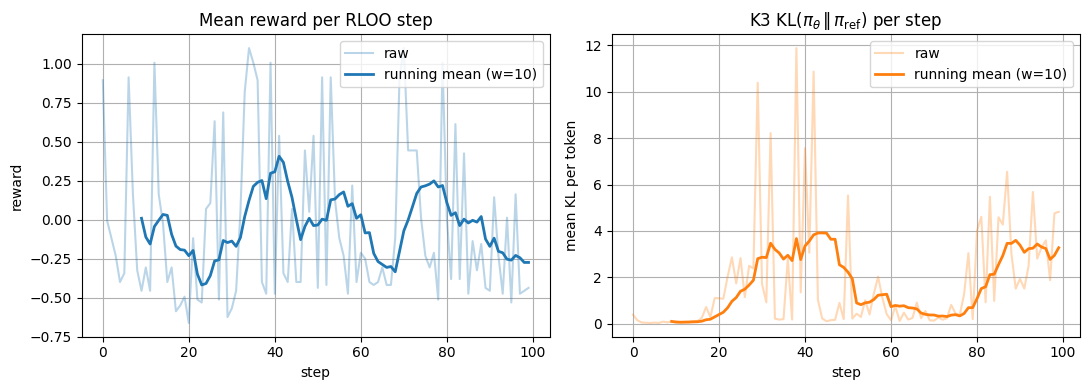

In [11]:
try:
    import matplotlib.pyplot as plt
    import numpy as np
except ImportError:
    print("matplotlib / numpy not installed — skipping plots.")
    print("Install with:  pip install matplotlib numpy")
else:
    def running_mean(x, w=10):
        x = np.asarray(x, dtype=float)
        if len(x) < w:
            return x
        return np.convolve(x, np.ones(w) / w, mode="valid")

    w = 10
    rm_r = running_mean(log_rewards, w)
    rm_k = running_mean(log_kls,     w)
    x_rm = np.arange(len(rm_r)) + (w - 1)  # align with the *end* of each window

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    ax[0].plot(log_steps, log_rewards, alpha=0.30, label="raw")
    ax[0].plot(x_rm, rm_r, color="tab:blue", linewidth=2, label=f"running mean (w={w})")
    ax[0].set(title="Mean reward per RLOO step", xlabel="step", ylabel="reward")
    ax[0].grid(True); ax[0].legend()

    ax[1].plot(log_steps, log_kls, color="tab:orange", alpha=0.30, label="raw")
    ax[1].plot(x_rm, rm_k, color="tab:orange", linewidth=2, label=f"running mean (w={w})")
    ax[1].set(title=r"K3 KL$(\pi_\theta \,\|\, \pi_\mathrm{ref})$ per step",
              xlabel="step", ylabel="mean KL per token")
    ax[1].grid(True); ax[1].legend()

    plt.tight_layout()
    plt.show()

Output results and hyperparameters in a text file

In [12]:
import datetime

# --- Metadata Configuration ---
MODEL_NAME = model_name
DATASET_NAME = "openai/gsm8k"   # Update with your actual dataset
OUTPUT_FILENAME = "data/training_report_{timestamp}.txt"

def save_report(filename, baseline, post, config, model_name, dataset_name):
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    filename = filename.format(timestamp=timestamp)

    with open(filename, "w", encoding="utf-8") as f:
        # 1. Header
        f.write("="*80 + "\n")
        f.write(f"{'REINFORCEMENT LEARNING TRAINING REPORT':^80}\n")
        f.write("="*80 + "\n\n")

        # 2. Run Metadata
        f.write("## RUN METADATA\n")
        f.write(f"Date:           {timestamp}\n")
        f.write(f"Model:          {model_name}\n")
        f.write(f"Dataset:        {dataset_name}\n\n")

        # 3. Hyperparameters
        f.write("## HYPERPARAMETERS\n")
        for key, value in config.items():
            f.write(f"{key:<20}: {value}\n")
        f.write("\n")

        # 4. Accuracy Comparison Table
        f.write("## PERFORMANCE COMPARISON\n")
        header = f"{'Metric':<28} | {'Baseline':<12} | {'Post-Training':<15} | {'Delta'}\n"
        f.write(header)
        f.write("-" * 80 + "\n")

        metrics = [
            ("Format Accuracy",   baseline.format_acc, post.format_acc),
            ("Answer Accuracy",   baseline.answer_acc, post.answer_acc),
            ("Combined Accuracy", baseline.both_acc,   post.both_acc),
        ]

        for label, b_val, p_val in metrics:
            delta = (p_val - b_val) * 100
            line = (f"{label:<28} | {b_val*100:>10.2f}% | "
                    f"{p_val*100:>13.2f}% | {delta:>+7.2f}%\n")
            f.write(line)

        if baseline.kl_div is not None and post.kl_div is not None:
            b_kl, p_kl = baseline.kl_div, post.kl_div
            delta_kl = p_kl - b_kl
            line = (f"{'KL(pi_theta || pi_ref) / token':<28} | "
                    f"{b_kl:>11.4f} | {p_kl:>14.4f} | {delta_kl:>+8.4f}\n")
            f.write(line)

        f.write("\n" + "="*80 + "\n")
        f.write("End of Report\n")

    print(f"✅ Report successfully saved to: {filename}")

# --- Execution ---
# Define the config dictionary for the report
current_config = {
    "Steps": n_steps,
    "Group Size (K)": K,
    "KL Coefficient": KL_COEF,
    "Clip Epsilon": CLIP_EPS,
    "PPO Epochs": PPO_EPOCHS,
    "Learning Rate": optimizer.param_groups[0]['lr']
}

# Generate and save
save_report(
    OUTPUT_FILENAME,
    results,       # Your baseline EvaluationSummary object
    post_summary,  # Your post-training EvaluationSummary object
    current_config,
    MODEL_NAME,
    DATASET_NAME
)


✅ Report successfully saved to: data/training_report_2026-05-08 14:07:18.txt
